<a href="https://colab.research.google.com/github/dcthyun0308/ESAA/blob/main/0410_%EC%84%B8%EC%85%98_%ED%8C%8C%EC%9D%B4%ED%86%A0%EC%B9%98_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01. PyTorch Workflow Exercise Template

The following is a template for the PyTorch workflow exercises.

It's only starter code and it's your job to fill in the blanks.

Because of the flexibility of PyTorch, there may be more than one way to answer the question.

Don't worry about trying to be *right* just try writing code that suffices the question.

You can see one form of [solutions on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions) (but try the exercises below yourself first!).

In [1]:
# Import necessary libraries
import torch
from torch import nn # nn은 신경망(Neural Networks)을 위한 모듈입니다.
import matplotlib.pyplot as plt

In [2]:
# Setup device-agnostic code
# GPU가 있으면 cuda를, 없으면 cpu를 사용하도록 설정합니다.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## 1. Create a straight line dataset using the linear regression formula (`weight * X + bias`).
  * Set `weight=0.3` and `bias=0.9` there should be at least 100 datapoints total.
  * Split the data into 80% training, 20% testing.
  * Plot the training and testing data so it becomes visual.

Your output of the below cell should look something like:
```
Number of X samples: 100
Number of y samples: 100
First 10 X & y samples:
X: tensor([0.0000, 0.0100, 0.0200, 0.0300, 0.0400, 0.0500, 0.0600, 0.0700, 0.0800,
        0.0900])
y: tensor([0.9000, 0.9030, 0.9060, 0.9090, 0.9120, 0.9150, 0.9180, 0.9210, 0.9240,
        0.9270])
```

Of course the numbers in `X` and `y` may be different but ideally they're created using the linear regression formula.

In [3]:
# Create the data parameters
weight = 0.3
bias = 0.9

# Make X and y using linear regression feature
start = 0
end = 1
step = 0.01

# X를 생성하고 (100, 1) 형태로 차원을 맞춥니다.
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

# 결과 확인용 (이미지에 있는 print문)
print(f"Number of X samples: {len(X)}")
print(f"Number of y samples: {len(y)}")
print(f"First 10 X & y samples:\nX: {X[:10]}\ny: {y[:10]}")

Number of X samples: 100
Number of y samples: 100
First 10 X & y samples:
X: tensor([[0.0000],
        [0.0100],
        [0.0200],
        [0.0300],
        [0.0400],
        [0.0500],
        [0.0600],
        [0.0700],
        [0.0800],
        [0.0900]])
y: tensor([[0.9000],
        [0.9030],
        [0.9060],
        [0.9090],
        [0.9120],
        [0.9150],
        [0.9180],
        [0.9210],
        [0.9240],
        [0.9270]])


In [4]:
# Split the data into training and testing
train_split = int(0.8 * len(X)) # 80%를 학습용으로 설정
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

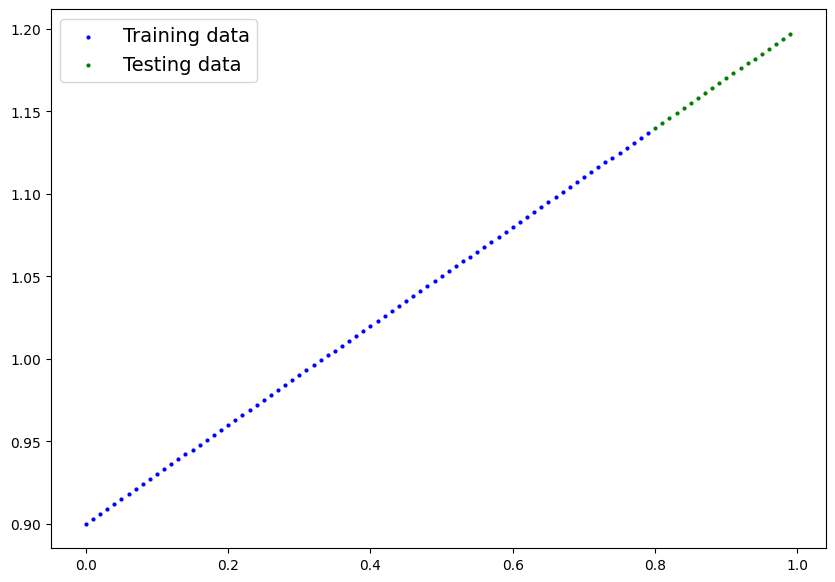

In [5]:
# Plot the training and testing data
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  """
  학습 데이터와 테스트 데이터를 시각화합니다.
  """
  plt.figure(figsize=(10, 7))

  # 학습 데이터는 파란색(blue)으로 표시
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # 테스트 데이터는 녹색(green)으로 표시
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # 예측값은 빨간색(red)으로 표시
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  plt.legend(prop={"size": 14})

plot_predictions()

## 2. Build a PyTorch model by subclassing `nn.Module`.
  * Inside should be a randomly initialized `nn.Parameter()` with `requires_grad=True`, one for `weights` and one for `bias`.
  * Implement the `forward()` method to compute the linear regression function you used to create the dataset in 1.
  * Once you've constructed the model, make an instance of it and check its `state_dict()`.
  * **Note:** If you'd like to use `nn.Linear()` instead of `nn.Parameter()` you can.

In [6]:
# Create PyTorch linear regression model by subclassing nn.Module
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        # nn.Parameter를 사용하여 가중치(weight)와 편향(bias)을 무작위로 초기화합니다.
        # requires_grad=True는 이 파라미터들이 학습(경사하강법)을 통해 업데이트되어야 함을 의미합니다.
        self.weights = nn.Parameter(torch.randn(1,
                                                requires_grad=True,
                                                dtype=torch.float))

        self.bias = nn.Parameter(torch.randn(1,
                                             requires_grad=True,
                                             dtype=torch.float))

    # 모델의 순전파(Forward propagation) 연산을 정의합니다.
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # 선형 회귀 공식: y = weights * x + bias
        return self.weights * x + self.bias

In [7]:
# Instantiate the model and put it to the target device
# 위에서 정의한 클래스로 모델 인스턴스를 생성하고 설정된 장치(GPU/CPU)로 보냅니다.
model_0 = LinearRegressionModelV2()
model_0.to(device)

# 모델의 상태(state_dict) 확인
print(f"모델 상태(state_dict):\n{model_0.state_dict()}")

모델 상태(state_dict):
OrderedDict({'weights': tensor([0.9096], device='cuda:0'), 'bias': tensor([-0.8996], device='cuda:0')})


## 3. Create a loss function and optimizer using `nn.L1Loss()` and `torch.optim.SGD(params, lr)` respectively.
  * Set the learning rate of the optimizer to be 0.01 and the parameters to optimize should be the model parameters from the model you created in 2.
  * Write a training loop to perform the appropriate training steps for 300 epochs.
  * The training loop should test the model on the test dataset every 20 epochs.

In [8]:
# Create the loss function and optimizer
# nn.L1Loss는 평균 절대 오차(MAE)를 계산합니다.
loss_fn = nn.L1Loss()

# SGD(확률적 경사하강법) 옵티마이저를 설정합니다.
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)

In [9]:
# Training loop
# Train model for 300 epochs
epochs = 300

# Send data to target device (데이터를 GPU/CPU로 이동)
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    ### Training
    # Put model in train mode (학습 모드로 전환)
    model_0.train()

    # 1. Forward pass (순전파: 예측값 계산)
    y_pred = model_0(X_train)

    # 2. Calculate loss (손실 계산)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero gradients (기울기 초기화)
    # 이전 루프의 기울기가 남지 않도록 매번 비워줘야 합니다.
    optimizer.zero_grad()

    # 4. Backpropagation (역전파: 기울기 계산)
    loss.backward()

    # 5. Step the optimizer (가중치 업데이트)
    optimizer.step()

    ### Perform testing every 20 epochs
    if epoch % 20 == 0:
        # Put model in evaluation mode and setup inference context
        model_0.eval() # 평가 모드 (드롭아웃, 배치 정규화 등 비활성화)
        with torch.inference_mode(): # 기울기 계산을 멈춰 메모리를 절약합니다.
            # 1. Forward pass
            test_pred = model_0(X_test)

            # 2. Calculate test loss
            test_loss = loss_fn(test_pred, y_test)

            # Print out what's happening
            print(f"Epoch: {epoch} | Train loss: {loss:.3f} | Test loss: {test_loss:.3f}")

Epoch: 0 | Train loss: 1.559 | Test loss: 1.240
Epoch: 20 | Train loss: 1.328 | Test loss: 0.970
Epoch: 40 | Train loss: 1.096 | Test loss: 0.699
Epoch: 60 | Train loss: 0.865 | Test loss: 0.428
Epoch: 80 | Train loss: 0.634 | Test loss: 0.158
Epoch: 100 | Train loss: 0.403 | Test loss: 0.113
Epoch: 120 | Train loss: 0.275 | Test loss: 0.297
Epoch: 140 | Train loss: 0.235 | Test loss: 0.385
Epoch: 160 | Train loss: 0.218 | Test loss: 0.426
Epoch: 180 | Train loss: 0.208 | Test loss: 0.442
Epoch: 200 | Train loss: 0.200 | Test loss: 0.444
Epoch: 220 | Train loss: 0.193 | Test loss: 0.438
Epoch: 240 | Train loss: 0.186 | Test loss: 0.428
Epoch: 260 | Train loss: 0.179 | Test loss: 0.413
Epoch: 280 | Train loss: 0.172 | Test loss: 0.398


## 4. Make predictions with the trained model on the test data.
  * Visualize these predictions against the original training and testing data (**note:** you may need to make sure the predictions are *not* on the GPU if you want to use non-CUDA-enabled libraries such as matplotlib to plot).

In [10]:
# Make predictions with the model
model_0.eval() # 평가 모드 전환

with torch.inference_mode():
    # 학습된 모델을 사용해 테스트 데이터에 대한 예측을 수행합니다.
    y_preds = model_0(X_test)

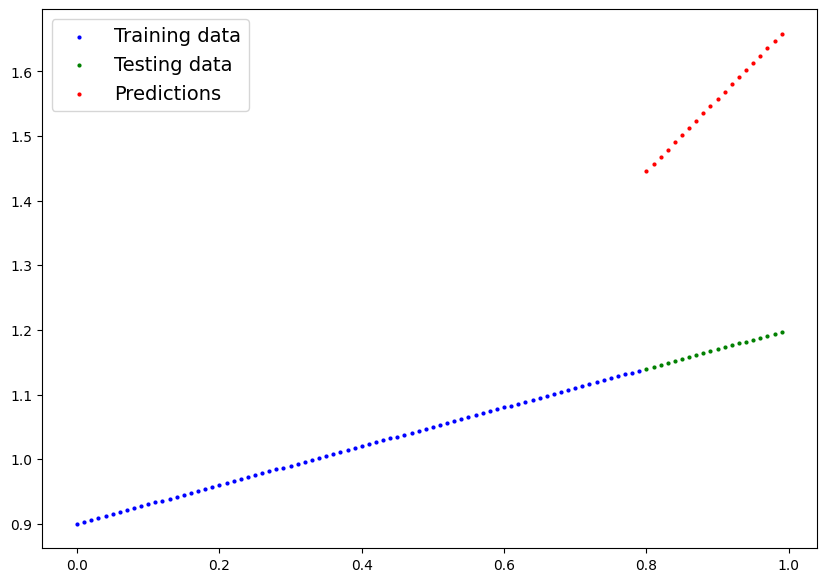

In [11]:
# Plot the predictions (these may need to be on a specific device)
plot_predictions(predictions=y_preds.cpu())

## 5. Save your trained model's `state_dict()` to file.
  * Create a new instance of your model class you made in 2. and load in the `state_dict()` you just saved to it.
  * Perform predictions on your test data with the loaded model and confirm they match the original model predictions from 4.

In [12]:
from pathlib import Path

# 1. Create models directory (모델을 저장할 폴더 만들기)
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path (저장할 파일 경로 설정)
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict (학습된 파라미터 저장)
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_0.pth


In [13]:
# Create new instance of model and load saved state dict (make sure to put it on the target device)
loaded_model_0 = LinearRegressionModelV2()
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))
loaded_model_0.to(device)

LinearRegressionModelV2()

In [15]:
# Make predictions with loaded model and compare them to the previous
loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test)

# 이전 예측값(y_preds)과 불러온 모델의 예측값이 일치하는지 확인
print(f"일치 여부: {torch.equal(y_preds, loaded_model_preds)}")

일치 여부: True
